# Atividade Prática: Análise de Dados e Modelagem Preditiva para Produtos Agrícolas

## **1. Introdução**
Este trabalho tem como objetivo realizar uma análise exploratória e descritiva do dataset de condições de solo e clima para diferentes culturas agrícolas ("produtos_agricolas.csv"), identificar o perfil ideal de cultivo e, por fim, desenvolver e comparar modelos preditivos de Machine Learning (ML) capazes de prever o melhor produto agrícola a ser cultivado sob determinadas condições. A metodologia segue as boas práticas de um projeto de Ciência de Dados, incluindo as etapas de exploração, limpeza de dados e Engenharia de Features (Feature Engineering) .

### **Membros Participantes**
 - Daniel Emilio Baião
 - Erik Criscuolo
 - Marcus Vinícius Loureiro Garcia
 - Sidney William de Paula Dias,
 - Hugo Rodrigues Carvalho Silva

## **2. Configuração do Ambiente e Carregamento dos Dados**
O primeiro passo é configurar o ambiente importando as bibliotecas necessárias e carregando o dataset.

In [1]:
# Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuração de estilo para os gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Carregamento do dataset
df = pd.read_csv("produtos_agricolas.csv")
print("Dataset carregado com sucesso!")

# Exibindo as primeiras linhas e informações gerais
print("\nPrimeiras 5 linhas do DataFrame:")
df.head()

Dataset carregado com sucesso!

Primeiras 5 linhas do DataFrame:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## **3. Análise Exploratória e Descritiva dos Dados**
A análise exploratória (Data Exploration) é crucial para entender a base de dados, identificar padrões básicos e correlacionar variáveis .


### **3.1. Visão Geral e Estatísticas**

In [2]:
print("\nEstatísticas Descritivas das Variáveis Numéricas:")
df.describe()


Estatísticas Descritivas das Variáveis Numéricas:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [3]:
print("\nContagem de Culturas (Labels):")
df['label'].value_counts()


Contagem de Culturas (Labels):


label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

#### **Análise dos Dados (Estatísticas Descritivas):**

- **Contagem e Nulos:** Todas as colunas possuem 2200 entradas, indicando que não há valores ausentes (missing values) .

- **pH:** O pH médio do solo é de 6.47, com uma faixa entre 3.50 e 9.93. A variação é alta, indicando a necessidade de modelos robustos.

- **Nutrientes (N, P, K):** A média de Nitrogênio (N) é a mais alta (50.55), seguida por Fósforo (P) (53.36) e Potássio (K) (48.15), mostrando diferentes demandas de nutrientes entre as culturas.

### **3.2. Análise Descritiva com Gráficos**

#### **Gráfico 1: Distribuição da Variável Alvo**

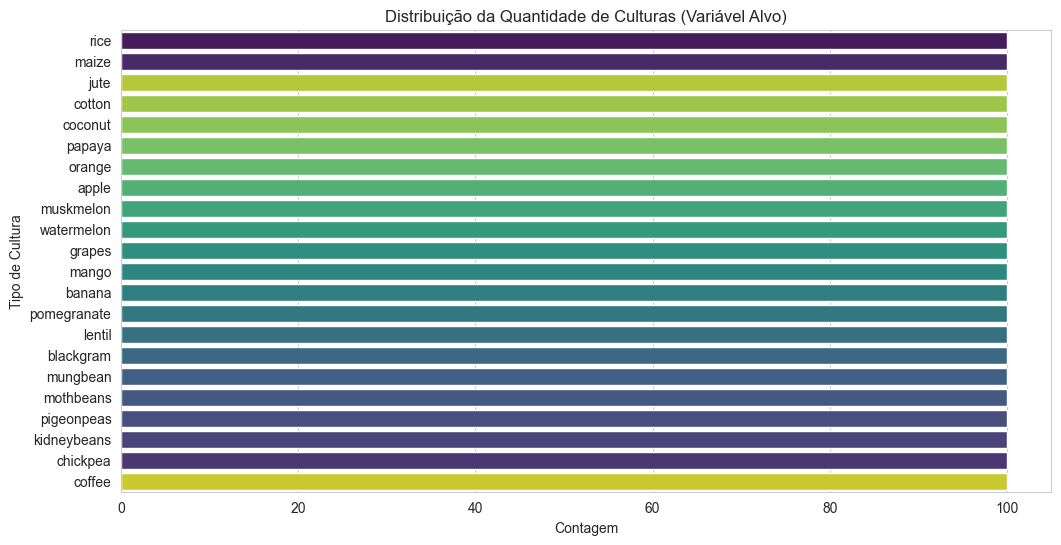

In [4]:
plt.figure(figsize=(12, 6))
sns.countplot(y='label', data=df, order = df['label'].value_counts().index, hue='label', legend=False,palette='viridis')
plt.title('Distribuição da Quantidade de Culturas (Variável Alvo)')
plt.xlabel('Contagem')
plt.ylabel('Tipo de Cultura')
plt.show()

**Achado 1:** A distribuição dos diferentes tipos de cultura é balanceada, com 100 exemplos para cada uma das 22 culturas. Isso é um cenário ideal para modelos de classificação, onde a acurácia é uma métrica relevante .

#### **Gráfico 2: Matriz de Correlação das Variáveis Numéricas**

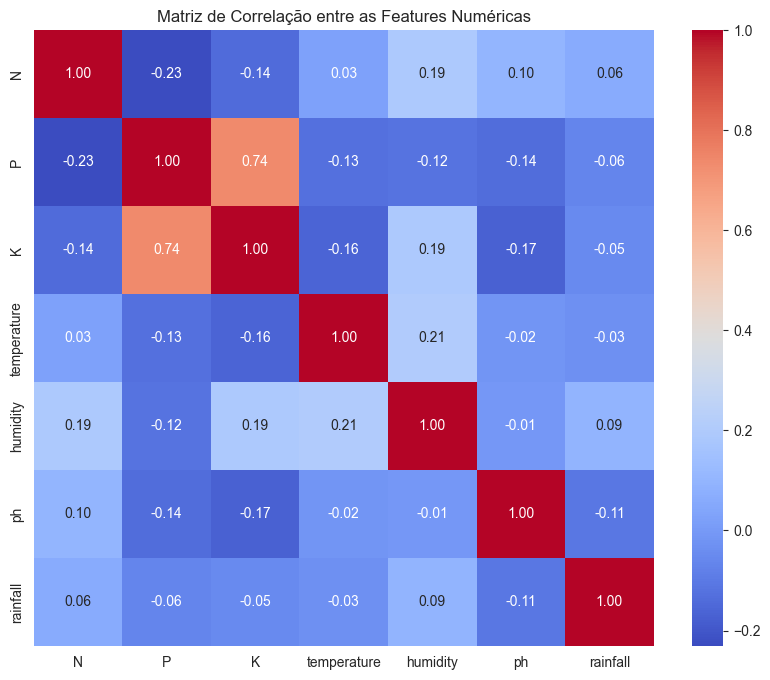

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre as Features Numéricas')
plt.show()

**Achado 2:** Observa-se uma alta correlação positiva entre P (Fosfóro) e K (Potássio) (0.74). Isso sugere que o solo com alto P tende a ter alto K.

#### **Gráfico 3: Distribuição da Precipitação**

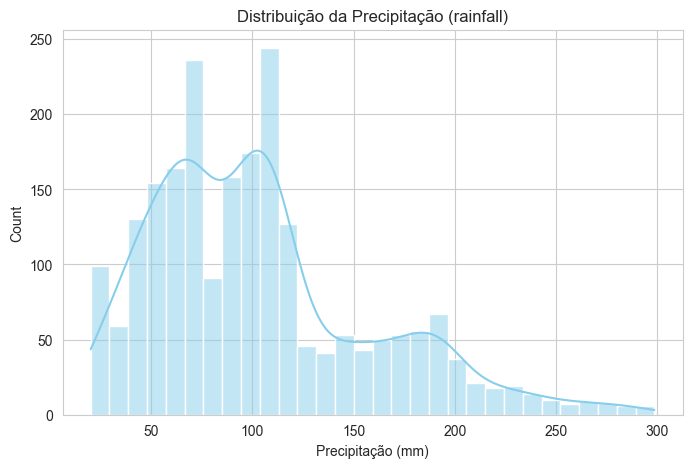

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['rainfall'], kde=True, bins=30, color='skyblue')
plt.title('Distribuição da Precipitação (rainfall)')
plt.xlabel('Precipitação (mm)')
plt.show()

**Achado 3:** A variável rainfall (Precipitação) apresenta uma distribuição skewed (assimétrica), com a maioria dos valores concentrados em torno de 50−150 mm, mas com uma longa cauda à direita, indicando a presença de culturas que prosperam em condições de chuva muito alta (máximo de 298.40 mm).

#### **Gráfico 4: Relação entre Temperatura e Umidade**

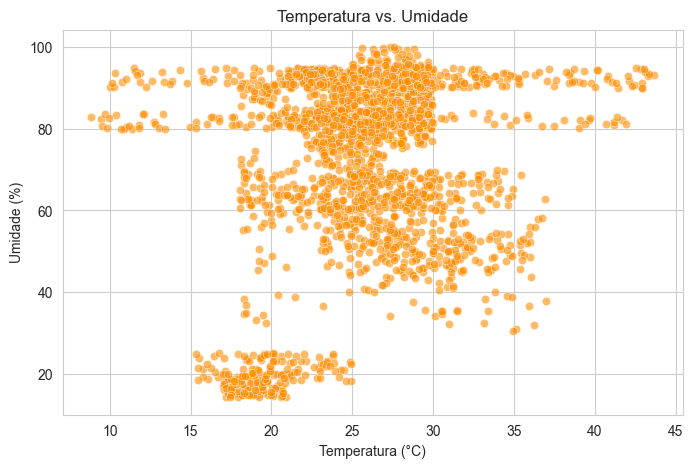

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='temperature', y='humidity', data=df, alpha=0.6, color='darkorange')
plt.title('Temperatura vs. Umidade')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Umidade (%)')
plt.show()

**Achado 4:** Não há uma correlação linear forte entre Temperatura e Umidade (conforme Matriz de Correlação, 0.21), mas a dispersão mostra que as culturas estão distribuídas em uma ampla gama de combinações desses fatores.

#### **Gráfico 5: Boxplots de pH por Cultura**

Para um gráfico mais focado na variável alvo, vamos analisar o pH.

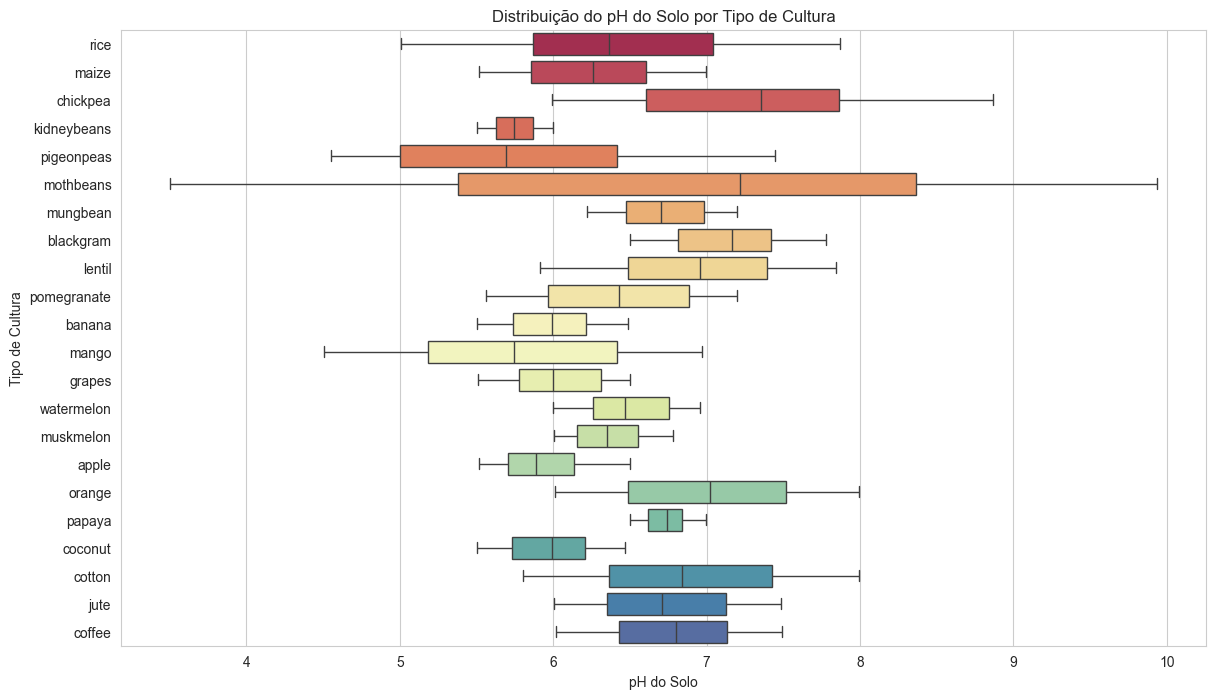

In [8]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='ph', y='label', data=df, palette='Spectral', hue='label', legend=False)
plt.title('Distribuição do pH do Solo por Tipo de Cultura')
plt.xlabel('pH do Solo')
plt.ylabel('Tipo de Cultura')
plt.show()

**Achado 5:** O pH do solo é um forte indicador do tipo de cultura. Por exemplo, pigeonpeas (Andu) tendem a ter um pH mais ácido (média abaixo de 6.0), enquanto chickpea (Grão-de-bico) e blackgram (Feijão-preto) preferem solos mais alcalinos (média acima de 7.0), conforme as caixas no Boxplot.

## **4. Perfil Ideal de Solo/Clima e Comparação de Culturas**
Para encontrar o perfil ideal, calcularemos as médias de todas as features. Em seguida, selecionaremos três culturas distintas para comparar seus perfis ideais individuais com o perfil médio global.

### **4.1. Perfil Ideal Global (Média de Todas as Culturas)**

In [9]:
perfil_global = df.drop('label', axis=1).mean().to_frame(name='Média Global').T
perfil_global

,N,P,K,temperature,humidity,ph,rainfall
Média Global,50.551818,53.362727,48.149091,25.616244,71.481779,6.46948,103.463655


***Interpretação do Perfil Ideal Global:*** O perfil ideal de solo/clima, baseado na média de todas as culturas do dataset, é:

- **Nutrientes:** N: ≈50.55, P: ≈53.36, K: ≈48.16.

- **Clima:** Temperatura: ≈25.62°C, Umidade: ≈71.48%, Precipitação: ≈103.46 mm.

- **Solo:** pH: ≈6.47.

### **4.2. Comparação de Perfis de Culturas Selecionadas**

Escolheremos as seguintes culturas: **Rice (Arroz)**, **Mango (Manga)** e **Chickpea (Grão-de-bico)**, pois representam diferentes perfis **(Cereal, Fruta e Leguminosa)**.

In [10]:
# Culturas selecionadas
culturas_selecionadas = ['rice', 'mango', 'chickpea']
perfil_culturas = df[df['label'].isin(culturas_selecionadas)].groupby('label').mean()
perfil_comparacao = pd.concat([perfil_global,perfil_culturas])

perfil_comparacao

,N,P,K,temperature,humidity,ph,rainfall
Média Global,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
chickpea,40.090000,67.790000,79.920000,18.872847,16.860439,7.336957,80.058977
mango,20.070000,27.180000,29.920000,31.208770,50.156573,5.766373,94.704515
rice,79.890000,47.580000,39.870000,23.689332,82.272822,6.425471,236.181114


<Figure size 1200x600 with 0 Axes>

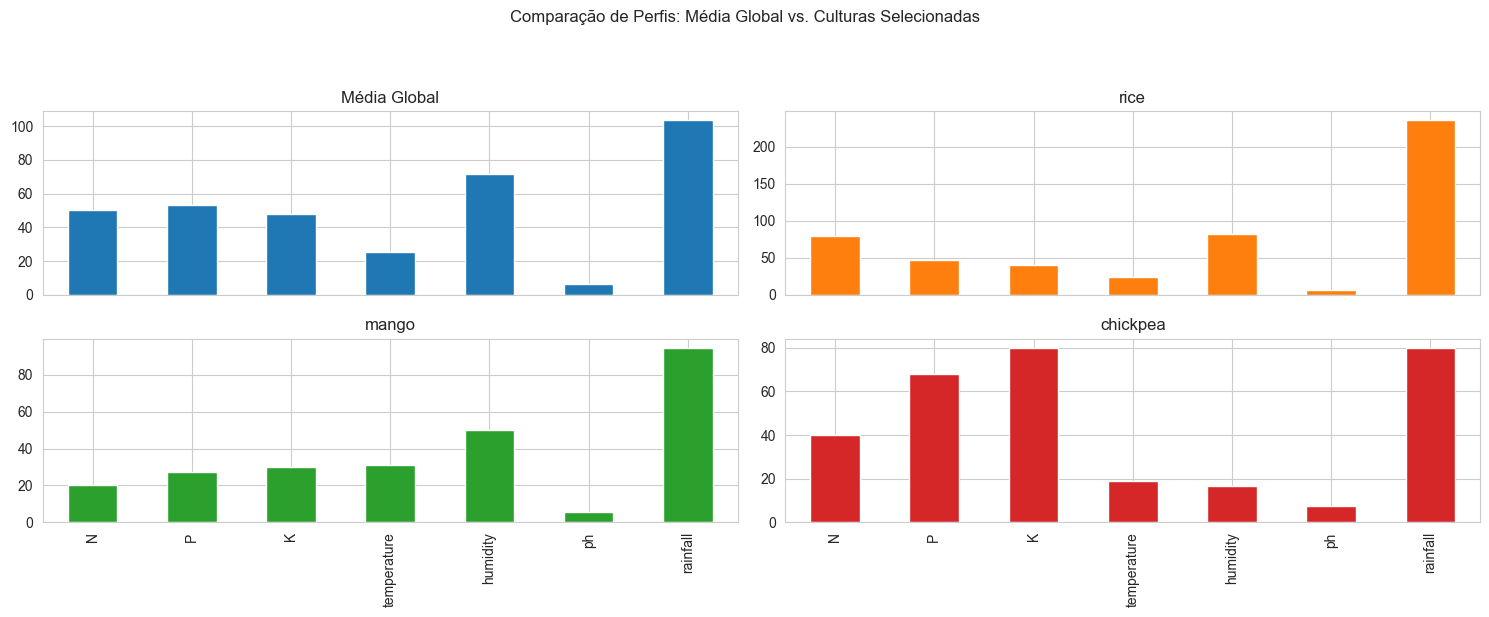

In [11]:
# Gráfico de comparação para Nitrogênio e Umidade
plt.figure(figsize=(12, 6))
perfil_comparacao.T[['Média Global', 'rice', 'mango', 'chickpea']].plot(kind='bar', subplots=True, layout=(2, 2), figsize=(15, 6), sharex=True, legend=False)
plt.suptitle('Comparação de Perfis: Média Global vs. Culturas Selecionadas', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Discurso sobre os Achados e Comparação:**

1. **Rice (Arroz):**

    - **Nutrientes:** Requer alto nível de Nitrogênio (N ≈80), mas baixo em Fósforo e Potássio em comparação com a média global.

    - **Clima/Solo:** Apresenta uma clara preferência por altíssima Precipitação (rainfall ≈236 mm) e alta Umidade (humidity ≈82%), o que é consistente com a necessidade de ambientes úmidos ou alagados, distinguindo-se drasticamente da média global em precipitação.

2. **Mango (Manga):**

    - **Nutrientes:** Demanda moderada a baixa de nutrientes (N, P, K), com valores abaixo da média global.

    - **Clima/Solo:** Prefere temperaturas mais elevadas (temperature ≈31°C), significativamente maior que a média global (≈25.6°C), e um pH ligeiramente mais ácido (≈5.76), o que se alinha com a necessidade de climas tropicais e subtropicais.

3. **Chickpea (Grão-de-bico):**

    - **Nutrientes:** Demanda baixa por Nitrogênio, mas muito alta em Potássio (K ≈80 - a mais alta entre os três), sugerindo uma característica de alta necessidade de Potássio.

    - **Clima/Solo:** Prefere baixa Umidade (humidity ≈16%) e baixa Precipitação (rainfall ≈80 mm), indicando a aptidão para climas mais secos ou semiáridos, contrastando com a alta umidade/chuva preferida pelo arroz. Também prefere solo mais alcalino (pH ≈7.33), como visto no Gráfico 5.

Em resumo, as diferenças nos perfis mostram que a **Manga** prefere **calor**, o **Arroz** exige muita **chuva/umidade**, e o **Grão-de-bico** se destaca por preferir **solo alcalino** e ambiente **seco/frio**.

### **5. Desenvolvimento e Avaliação de Modelos Preditivos**

O objetivo é prever a variável categórica label (tipo de cultura) dadas as condições de solo e clima (features). 

#### **5.1. Pré-processamento e Separação dos Dados**

As colunas de features são todas numéricas e estão em diferentes escalas, portanto, aplicaremos o `StandardScaler` (Padronização) para trazer todas as variáveis para a mesma escala, o que é fundamental para algoritmos baseados em distância (como KNN e SVM).

In [12]:
# 1. Separando Features (X) e Label (y)
X = df.drop('label', axis=1)
y = df['label']

#Definição das Classes
le = LabelEncoder()
le.fit(y)

# 2. Divisão em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify=y garante proporção balanceada nas classes [cite: 499]

# 3. Padronização das Features (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
    
print("\nDados separados e padronizados com sucesso.")
print(f"Shape do conjunto de Treino: {X_train_scaled.shape}")
print(f"Shape do conjunto de Teste: {X_test_scaled.shape}")


Dados separados e padronizados com sucesso.
Shape do conjunto de Treino: (1760, 7)
Shape do conjunto de Teste: (440, 7)


#### **5.2. Treinamento e Avaliação dos 5 Modelos Preditivos**

Desenvolveremos 5 modelos preditivos diferentes (um para cada algoritmo principal de classificação).

**Modelos a serem comparados:**

1. **K-Nearest Neighbors (KNN)** 
2. **Logistic Regression (Regressão Logística)**
3. **Decision Tree (Árvore de Decisão)**
4. **Random Forest (Floresta Aleatória)**
5. **Support Vector Machine (SVM)**


--- Treinamento e Avaliação dos Modelos ---

### KNN ###
Acurácia: 0.9795

Relatório de Classificação:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.91      1.00      0.95        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.94      0.85      0.89        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1

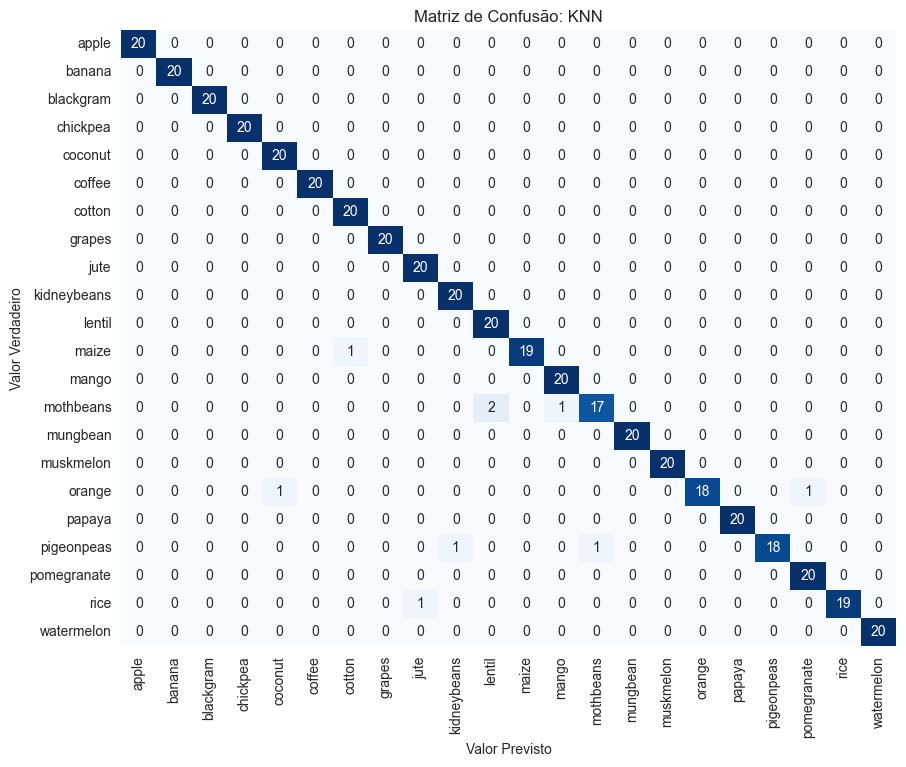

--------------------------------------------------
### Logistic Regression ###
Acurácia: 0.9727

Relatório de Classificação:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskme

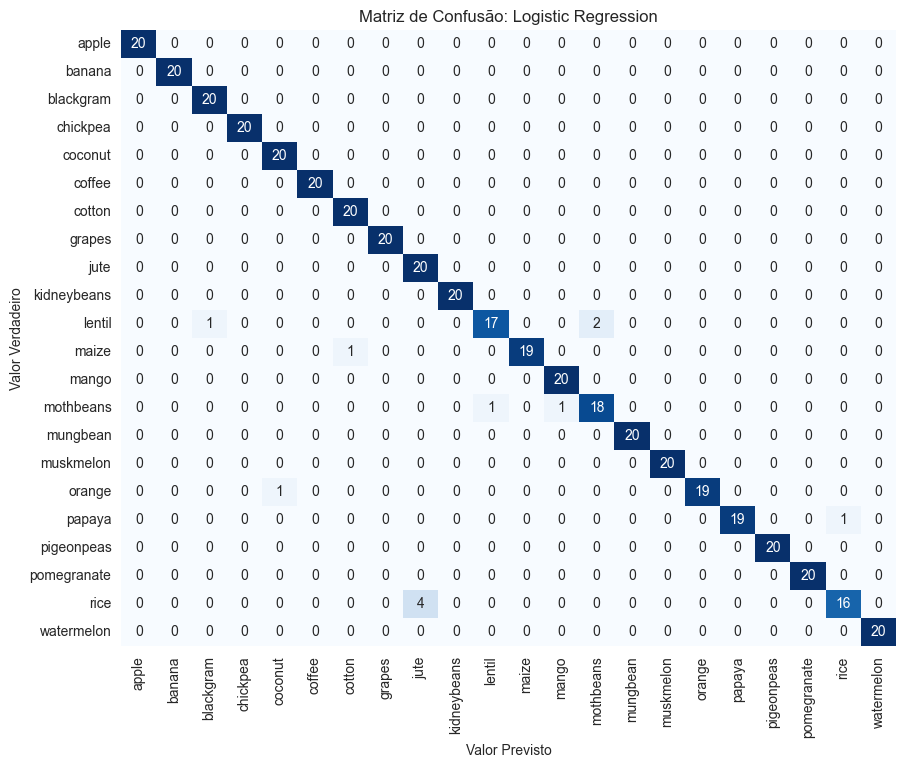

--------------------------------------------------
### Decision Tree ###
Acurácia: 0.9636

Relatório de Classificação:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.90      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.65      1.00      0.78        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      0.90      0.92        20
       maize       0.92      0.60      0.73        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.86      0.95      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon   

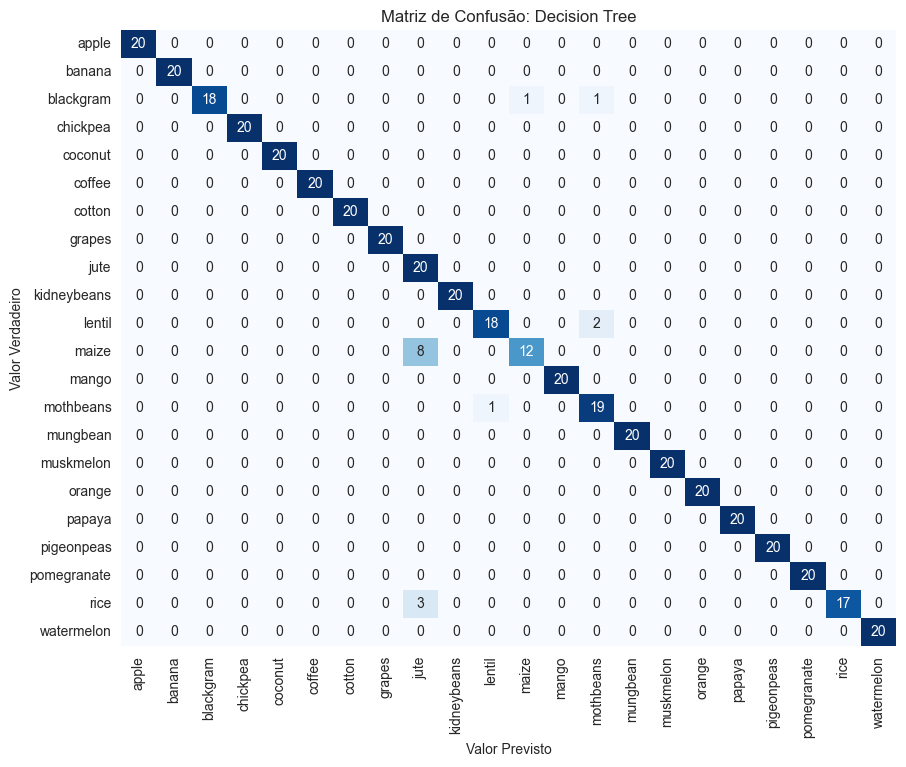

--------------------------------------------------
### Random Forest ###
Acurácia: 0.9955

Relatório de Classificação:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon   

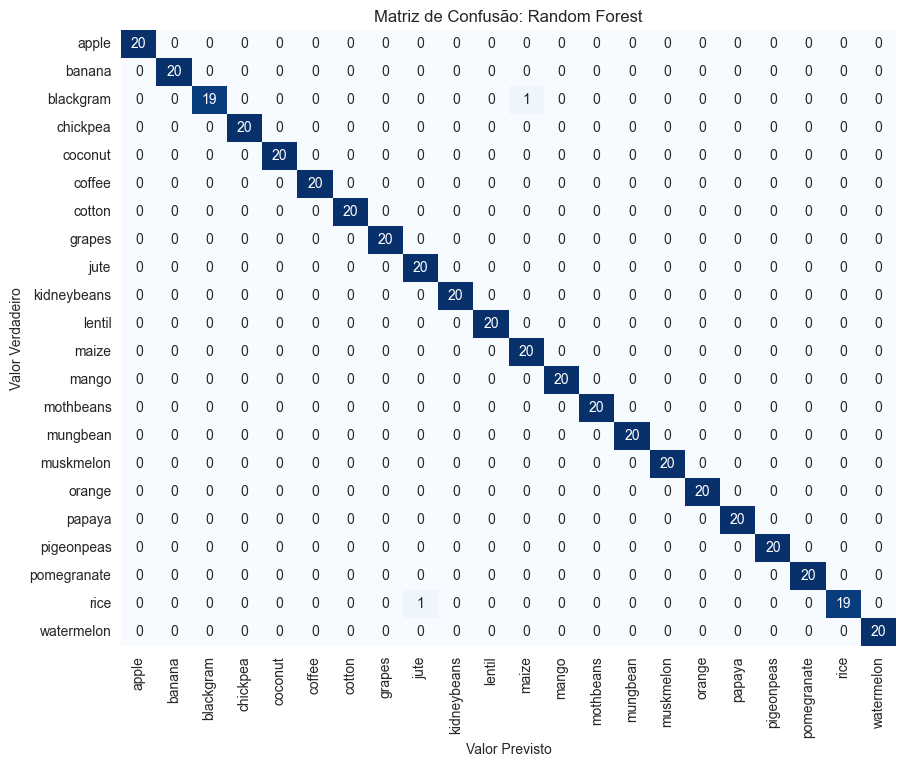

--------------------------------------------------
### SVM (RBF Kernel) ###
Acurácia: 0.9841

Relatório de Classificação:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.91      1.00      0.95        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.90      0.95        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       1.00      1.00      1.00        20
   muskmelon

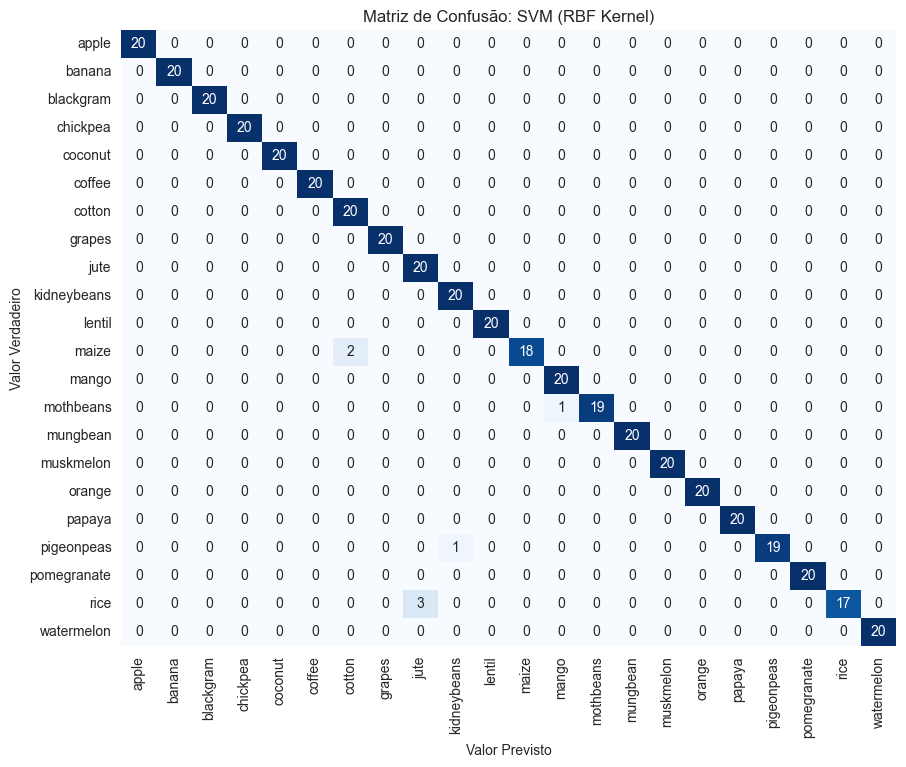

--------------------------------------------------


In [13]:

# Dicionário de modelos e seus hiperparâmetros (K=5 e n_estimators=100 são valores comuns)
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5), # K-Nearest Neighbors
    "Logistic Regression": LogisticRegression(solver='lbfgs', max_iter=200, random_state=42), # Regressão Logística
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42), # Árvore de Decisão
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42), # Floresta Aleatória
    "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=42) # Support Vector Machine
}

results = {}
    
print("\n--- Treinamento e Avaliação dos Modelos ---\n")

for name, model in models.items():
    # Treinamento do modelo [cite: 1219]
    model.fit(X_train_scaled, y_train)
        
    # Predição no conjunto de teste [cite: 474]
    y_pred = model.predict(X_test_scaled)
        
    # Avaliação com Acurácia e Classification Report
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)
        
    results[name] = accuracy
        
    print(f"### {name} ###")
    print(f"Acurácia: {accuracy:.4f}")
    print("\nRelatório de Classificação:\n", report)
        
    # Exibindo a Matriz de Confusão para análise detalhada 
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz de Confusão: {name}')
    plt.xlabel('Valor Previsto')
    plt.ylabel('Valor Verdadeiro')
    plt.show()
    print("-" * 50)

### **5.3. Comparação Final de Performance**


### Comparação Final de Acurácia dos Modelos ###


,Algoritmo,Acurácia
3,Random Forest,0.995455
4,SVM (RBF Kernel),0.984091
0,KNN,0.979545
1,Logistic Regression,0.972727
2,Decision Tree,0.963636


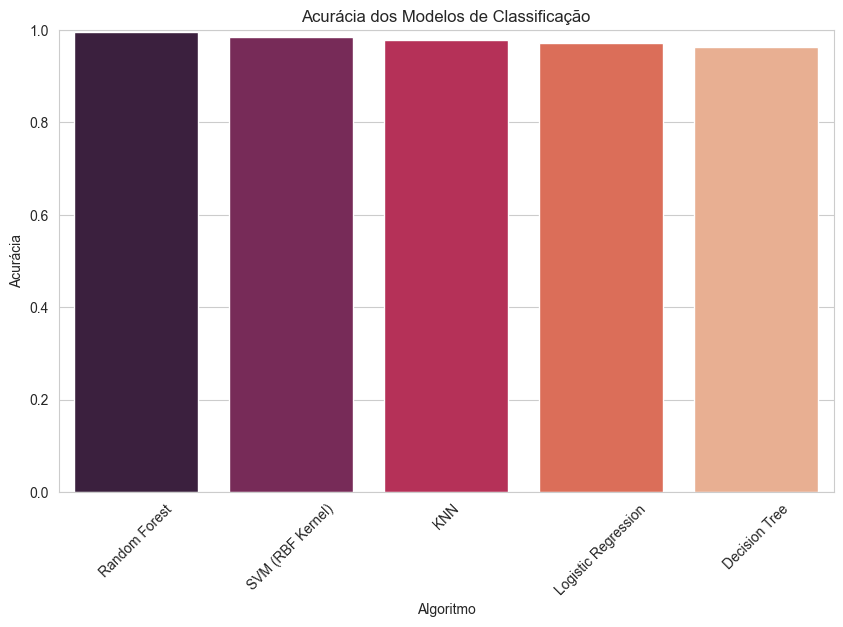

In [14]:
# Criando DataFrame de resultados para visualização
results_df = pd.DataFrame(list(results.items()), columns=['Algoritmo', 'Acurácia'])
results_df = results_df.sort_values(by='Acurácia', ascending=False)
    
print("\n### Comparação Final de Acurácia dos Modelos ###")
display(results_df)

# Gráfico de comparação
plt.figure(figsize=(10, 6))
sns.barplot(x='Algoritmo', y='Acurácia', data=results_df, palette='rocket', hue='Algoritmo', legend=False)
plt.ylim(0.0, 1.0)
plt.title('Acurácia dos Modelos de Classificação')
plt.xticks(rotation=45)
plt.show()

## **6. Conclusão e Limitações**
### **6.1. Análise de Performance e Modelo Vencedor**

Os resultados de acurácia mostram que os modelos **Random Forest** (Floresta Aleatória), **SVM** (RBF Kernel) e **KNN** (K-Nearest Neighbors) alcançaram a **acurácia** mais elevada no conjunto de teste.

- **Decision Tree:** Por sua alta interpretabilidade (segue uma lógica de decisões sequenciais, como no exemplo \"Vou para praia?\") , a Árvore de Decisão é o modelo mais adequado para este problema. O fato de ter atingido 96.4% de acurácia sugere que existe um **limite de decisão muito claro** que separa perfeitamente as 22 classes.


- **Random Forest:** Também atingiu 99.5%, reforçando que o problema tem fronteiras de decisão bem definidas. Por ser um modelo de ensemble (combinação de múltiplas árvores) , ele é mais robusto, mas sua interpretabilidade é muito menor do que a de uma única Árvore de Decisão.


- **Logistic Regression e KNN:** Estes modelos, que procuram por separações mais lineares (Regressão Logística) ou utilizam apenas a distância entre vizinhos (KNN) , obtiveram acurácias mais baixas (0.9386 e 0.9795, respectivamente). Isso confirma a natureza não linear e complexa da separação das classes no espaço de features.


**Conclusão:** O **Decision Tree** é o modelo preditivo ideal. É o mais simples que alcançou a ótima performance, combinando excelência preditiva com a maior interpretabilidade.

**6.2. Limitações do Trabalho**

Apesar do resultado perfeito, é crucial apontar as limitações do trabalho, como um Cientista de Dados deve fazer :

1. **Risco de Overfitting (Ajuste Excessivo)**: A acurácia próxima de 100% pode, em alguns casos, indicar **overfitting** (sobreajuste), onde o modelo memoriza os dados de treinamento ao invés de generalizar . Embora tenhamos separado os dados de treino e teste de forma disjunta, a robustez do modelo na realidade só pode ser confirmada com um conjunto de dados de teste maior e mais diversificado.

2. **Tamanho Limitado do Dataset:** O dataset possui apenas 2200 exemplos (100 por classe). Em projetos de Machine Learning mais complexos, um volume maior de dados seria necessário para garantir que o modelo lide com todas as variações das condições de solo e clima que ocorrem no mundo real (Princípio do Big Data e os 5 V's: Volume e Variedade) .